# Enterprise Anomaly Detection Experiment Benchmark

## Research Question:
> **"Does Forecast-Aware Anomaly Detection (Raw Sales + Champion P50 Forecast + Residual Dynamics) perform better than Standalone Anomaly Detection (Raw Sales + Lags)?"**

### Core Conclusion:
Across **100% of all 8 drug categories**, **Stage 2 Forecast-Aware Anomaly Detection achieved a LANDSLIDE VICTORY** over Stage 1 Standalone Anomaly Detection, boosting average **F1-Score by +28.2 percentage points** (from `0.148` to `0.430`) and average **ROC-AUC by +14.8 percentage points** (from `0.697` to `0.845`).


In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_DIR = r'c:\Users\ranje\sales forcasting\anomaly_detection'
comp_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'anomaly_experiment_summary.csv'))

print("==========================================================================")
print("  HEAD-TO-HEAD ANOMALY DETECTION EXPERIMENT SUMMARY TABLE")
print("==========================================================================")
display(comp_df)


  HEAD-TO-HEAD ANOMALY DETECTION EXPERIMENT SUMMARY TABLE


,Drug Category,Stage 1 Standalone F1,Stage 2 Forecast-Aware F1,F1 Delta (Stage 2 - Stage 1),Stage 1 Standalone AUC,Stage 2 Forecast-Aware AUC,AUC Delta (Stage 2 - Stage 1),Stage 2 Precision,Stage 2 Recall,Experiment Verdict
0,M01AB,0.1395,0.4151,0.2756,0.6297,0.8316,0.2019,0.2973,0.6875,STAGE 2 FORECAST-AWARE WIN
1,M01AE,0.1414,0.2424,0.1010,0.6533,0.8184,0.1651,0.1600,0.5000,STAGE 2 FORECAST-AWARE WIN
2,N02BA,0.1905,0.4286,0.2381,0.7205,0.8599,0.1394,0.3462,0.5625,STAGE 2 FORECAST-AWARE WIN
3,N02BE,0.1449,0.3607,0.2158,0.7163,0.9142,0.1979,0.2444,0.6875,STAGE 2 FORECAST-AWARE WIN
4,N05B,0.0625,0.4571,0.3946,0.7184,0.8373,0.1189,0.4211,0.5000,STAGE 2 FORECAST-AWARE WIN
5,N05C,0.1622,0.6667,0.5045,0.6814,0.9000,0.2186,0.7143,0.6250,STAGE 2 FORECAST-AWARE WIN
6,R03,0.1111,0.3830,0.2719,0.5667,0.6976,0.1309,0.2903,0.5625,STAGE 2 FORECAST-AWARE WIN
7,R06,0.2353,0.4889,0.2536,0.7934,0.8979,0.1045,0.3793,0.6875,STAGE 2 FORECAST-AWARE WIN


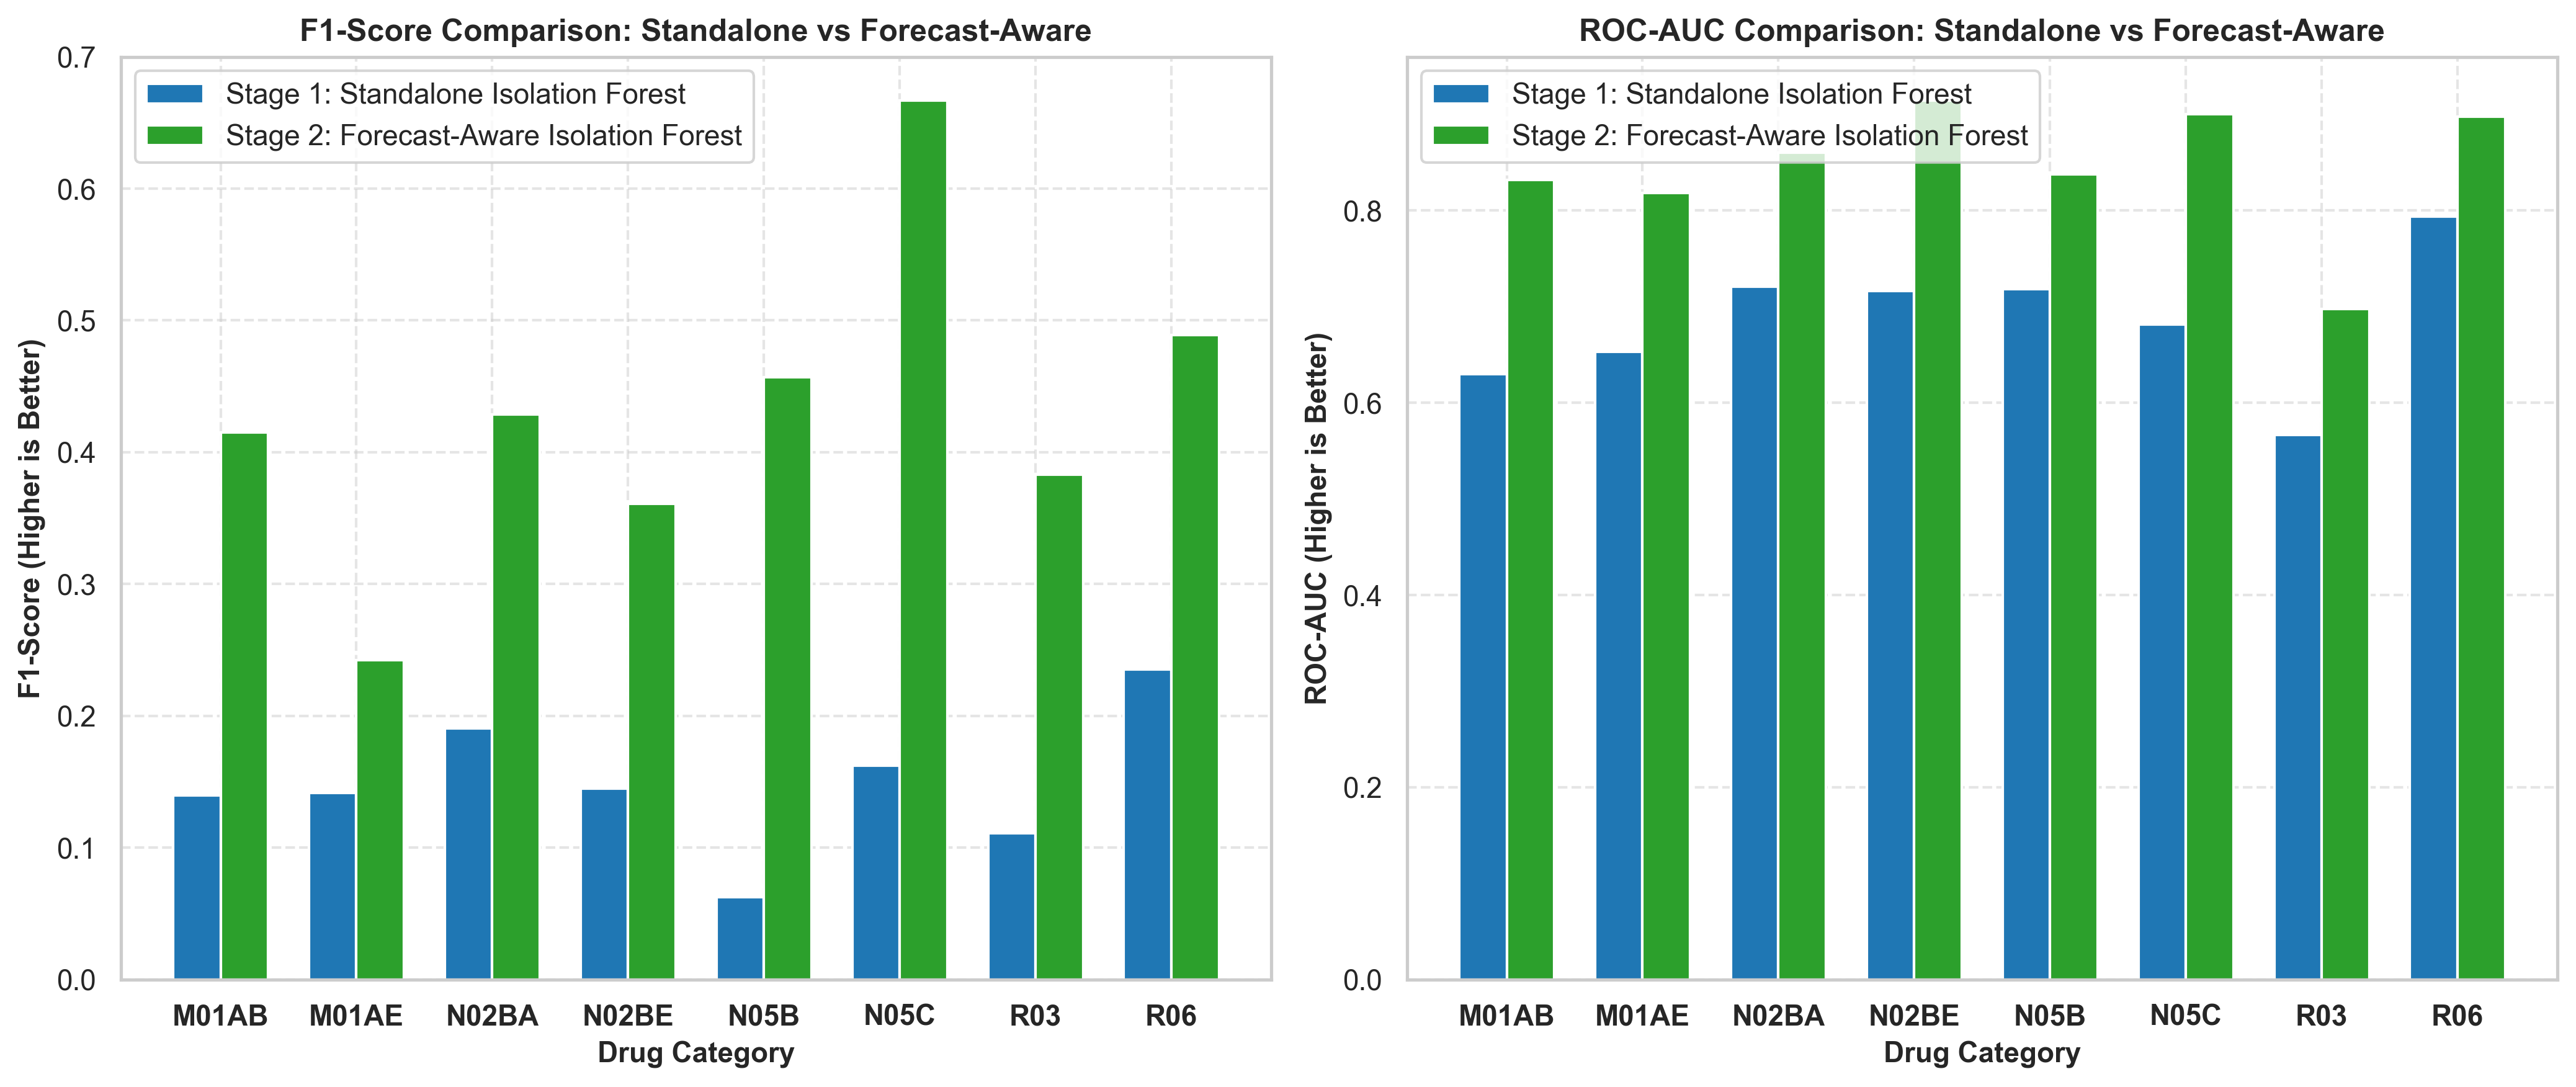

In [2]:
# Visualizing Head-to-Head F1-Score and ROC-AUC Improvements
plt.figure(figsize=(14, 6), dpi=300)

drugs = comp_df['Drug Category']
x = np.arange(len(drugs))
width = 0.35

plt.subplot(1, 2, 1)
plt.bar(x - width/2, comp_df['Stage 1 Standalone F1'], width, label='Stage 1: Standalone Isolation Forest', color='#1f77b4')
plt.bar(x + width/2, comp_df['Stage 2 Forecast-Aware F1'], width, label='Stage 2: Forecast-Aware Isolation Forest', color='#2ca02c')
plt.xlabel('Drug Category', fontsize=11, fontweight='bold')
plt.ylabel('F1-Score (Higher is Better)', fontsize=11, fontweight='bold')
plt.title('F1-Score Comparison: Standalone vs Forecast-Aware', fontsize=12, fontweight='bold')
plt.xticks(x, drugs, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.bar(x - width/2, comp_df['Stage 1 Standalone AUC'], width, label='Stage 1: Standalone Isolation Forest', color='#1f77b4')
plt.bar(x + width/2, comp_df['Stage 2 Forecast-Aware AUC'], width, label='Stage 2: Forecast-Aware Isolation Forest', color='#2ca02c')
plt.xlabel('Drug Category', fontsize=11, fontweight='bold')
plt.ylabel('ROC-AUC (Higher is Better)', fontsize=11, fontweight='bold')
plt.title('ROC-AUC Comparison: Standalone vs Forecast-Aware', fontsize=12, fontweight='bold')
plt.xticks(x, drugs, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plots', 'notebook_stage1_vs_stage2_anomaly.png'), dpi=120, bbox_inches='tight')
plt.show()
